# Chapter 6: Case Study 3
#The dataset used in this case study is the result from Chapter 7

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

## Input file preprocessing

In [ ]:
# Basecalling using Dorado
! /projects/health_sciences/bms/biochemistry/lim_group/cslim/mod/src/dorado-0.9.1-linux-x64/bin/dorado duplex sup  pod5/RPD33S_1_sample_1.pod5 > duplex.bam
! samtools fastq -T "mv,ts,pi,sp,ns,dx" duplex.bam | gzip > duplex.fastq.gz # get the dx tag when converting files to fastq format

In [ ]:
# Mapping to reference sequence
! minimap2 -a -x map-ont -y --secondary=no --sam-hit-only ../ref/variants_mx3c.mmi duplex.fastq.gz > duplex_mapped.sam 
! samtools view -b duplex_mapped.sam -o duplex_mapped.bam # converting sam file to bam file
! samtools view -F2304 dorado/duplex_mapped.bam | awk '/dx:i:1/ || /dx:i:0/ {print $1 "\t" $3 "\t" $10}' | gzip > mut_lib_duplex_mapped.txt.gz # exclude those that are not in primary alignment and supplementary alignment

## Snipseq

In [ ]:
# Defining pair patterns

pair11 = r"""(?x)
(?P<barcode_f>TTCTAGCT){e<=1}
(?P<lead>TCGTCGGCAGCGTCAGATGTGTATAAGAGACAG){e<=1}
(?P<umi_f>.{2})
(?P<pT_fwd>GTGTTCACTAGCAACCTCAAAC){e<=1}
(?P<flank>ATTC){e<=1}
(?P<up_v>.{1})
(?P<cons_v>TCATG){e<=1}
(?P<down_v>.{2})
(?P<sequence>.{575,585})
(?P<pT_rev>GAGAGAGTCACCACATACGAAG){e<=1}
(?P<umi_r>.{2})
(?P<trail>CTGTCTCTTATACACATCTCCGAGCCCACGAGAC){e<=1}
(?P<barcode_r>ATCTCAGG){e<=1}
"""
pair12 = r"""(?x)
(?P<barcode_f>AAGGCTAT){e<=1}
(?P<lead>TCGTCGGCAGCGTCAGATGTGTATAAGAGACAG){e<=1}
(?P<umi_f>.{2})
(?P<pT_fwd>GTGTTCACTAGCAACCTCAAAC){e<=1}
(?P<flank>ATTC){e<=1}
(?P<up_v>.{1})
(?P<cons_v>TCATG){e<=1}
(?P<down_v>.{2})
(?P<sequence>.{575,585})
(?P<pT_rev>GAGAGAGTCACCACATACGAAG){e<=1}
(?P<umi_r>.{2})
(?P<trail>CTGTCTCTTATACACATCTCCGAGCCCACGAGAC){e<=1}
(?P<barcode_r>CGAGGCTG){e<=1}
"""

pair13 = r"""(?x)
(?P<barcode_f>AAGGCTAT){e<=1}
(?P<lead>TCGTCGGCAGCGTCAGATGTGTATAAGAGACAG){e<=1}
(?P<umi_f>.{2})
(?P<pT_fwd>GTGTTCACTAGCAACCTCAAAC){e<=1}
(?P<flank>ATTC){e<=1}
(?P<up_v>.{1})
(?P<cons_v>TCATG){e<=1}
(?P<down_v>.{2})
(?P<sequence>.{575,585})
(?P<pT_rev>GAGAGAGTCACCACATACGAAG){e<=1}
(?P<umi_r>.{2})
(?P<trail>CTGTCTCTTATACACATCTCCGAGCCCACGAGAC){e<=1}
(?P<barcode_r>ATCTCAGG){e<=1}
"""

pair14 = r"""(?x)
(?P<barcode_f>TTCTAGCT){e<=1}
(?P<lead>TCGTCGGCAGCGTCAGATGTGTATAAGAGACAG){e<=1}
(?P<umi_f>.{2})
(?P<pT_fwd>GTGTTCACTAGCAACCTCAAAC){e<=1}
(?P<flank>ATTC){e<=1}
(?P<up_v>.{1})
(?P<cons_v>TCATG){e<=1}
(?P<down_v>.{2})
(?P<sequence>.{575,585})
(?P<pT_rev>GAGAGAGTCACCACATACGAAG){e<=1}
(?P<umi_r>.{2})
(?P<trail>CTGTCTCTTATACACATCTCCGAGCCCACGAGAC){e<=1}
(?P<barcode_r>CGAGGCTG){e<=1}
"""

pair21 = r"""(?x)
(?P<barcode_f>CTCTCTAT){e<=1}
(?P<lead>TCGTCGGCAGCGTCAGATGTGTATAAGAGACAG){e<=1}
(?P<umi_f>.{2})
(?P<pT_fwd>GTGTTCACTAGCAACCTCAAAC){e<=1}
(?P<flank>ATTC){e<=1}
(?P<up_v>.{1})
(?P<cons_v>TCATG){e<=1}
(?P<down_v>.{2})
(?P<sequence>.{575,585})
(?P<pT_rev>GAGAGAGTCACCACATACGAAG){e<=1}
(?P<umi_r>.{2})
(?P<trail>CTGTCTCTTATACACATCTCCGAGCCCACGAGAC){e<=1}
(?P<barcode_r>TGCCTCTT){e<=1}
"""
pair22 = r"""(?x)
(?P<barcode_f>CGTACAAT){e<=1}
(?P<lead>TCGTCGGCAGCGTCAGATGTGTATAAGAGACAG){e<=1}
(?P<umi_f>.{2})
(?P<pT_fwd>GTGTTCACTAGCAACCTCAAAC){e<=1}
(?P<flank>ATTC){e<=1}
(?P<up_v>.{1})
(?P<cons_v>TCATG){e<=1}
(?P<down_v>.{2})
(?P<sequence>.{575,585})
(?P<pT_rev>GAGAGAGTCACCACATACGAAG){e<=1}
(?P<umi_r>.{2})
(?P<trail>CTGTCTCTTATACACATCTCCGAGCCCACGAGAC){e<=1}
(?P<barcode_r>TCCTCTAC){e<=1}
"""

pair23 = r"""(?x)
(?P<barcode_f>CGTACAAT){e<=1}
(?P<lead>TCGTCGGCAGCGTCAGATGTGTATAAGAGACAG){e<=1}
(?P<umi_f>.{2})
(?P<pT_fwd>GTGTTCACTAGCAACCTCAAAC){e<=1}
(?P<flank>ATTC){e<=1}
(?P<up_v>.{1})
(?P<cons_v>TCATG){e<=1}
(?P<down_v>.{2})
(?P<sequence>.{575,585})
(?P<pT_rev>GAGAGAGTCACCACATACGAAG){e<=1}
(?P<umi_r>.{2})
(?P<trail>CTGTCTCTTATACACATCTCCGAGCCCACGAGAC){e<=1}
(?P<barcode_r>TGCCTCTT){e<=1}
"""

pair24 = r"""(?x)
(?P<barcode_f>CTCTCTAT){e<=1}
(?P<lead>TCGTCGGCAGCGTCAGATGTGTATAAGAGACAG){e<=1}
(?P<umi_f>.{2})
(?P<pT_fwd>GTGTTCACTAGCAACCTCAAAC){e<=1}
(?P<flank>ATTC){e<=1}
(?P<up_v>.{1})
(?P<cons_v>TCATG){e<=1}
(?P<down_v>.{2})
(?P<sequence>.{575,585})
(?P<pT_rev>GAGAGAGTCACCACATACGAAG){e<=1}
(?P<umi_r>.{2})
(?P<trail>CTGTCTCTTATACACATCTCCGAGCCCACGAGAC){e<=1}
(?P<barcode_r>TCCTCTAC){e<=1}
"""

pair31 = r"""(?x)
(?P<barcode_f>CTCTCTAT){e<=1}
(?P<lead>TCGTCGGCAGCGTCAGATGTGTATAAGAGACAG){e<=1}
(?P<umi_f>.{2})
(?P<pT_fwd>GTGTTCACTAGCAACCTCAAAC){e<=1}
(?P<flank>ATTC){e<=1}
(?P<up_v>.{1})
(?P<cons_v>TCATG){e<=1}
(?P<down_v>.{2})
(?P<sequence>.{575,585})
(?P<pT_rev>GAGAGAGTCACCACATACGAAG){e<=1}
(?P<umi_r>.{2})
(?P<trail>CTGTCTCTTATACACATCTCCGAGCCCACGAGAC){e<=1}
(?P<barcode_r>ATCTCAGG){e<=1}
"""
pair32 = r"""(?x)
(?P<barcode_f>CGTACAAT){e<=1}
(?P<lead>TCGTCGGCAGCGTCAGATGTGTATAAGAGACAG){e<=1}
(?P<umi_f>.{2})
(?P<pT_fwd>GTGTTCACTAGCAACCTCAAAC){e<=1}
(?P<flank>ATTC){e<=1}
(?P<up_v>.{1})
(?P<cons_v>TCATG){e<=1}
(?P<down_v>.{2})
(?P<sequence>.{575,585})
(?P<pT_rev>GAGAGAGTCACCACATACGAAG){e<=1}
(?P<umi_r>.{2})
(?P<trail>CTGTCTCTTATACACATCTCCGAGCCCACGAGAC){e<=1}
(?P<barcode_r>CGAGGCTG){e<=1}
"""

pair33 = r"""(?x)
(?P<barcode_f>CGTACAAT){e<=1}
(?P<lead>TCGTCGGCAGCGTCAGATGTGTATAAGAGACAG){e<=1}
(?P<umi_f>.{2})
(?P<pT_fwd>GTGTTCACTAGCAACCTCAAAC){e<=1}
(?P<flank>ATTC){e<=1}
(?P<up_v>.{1})
(?P<cons_v>TCATG){e<=1}
(?P<down_v>.{2})
(?P<sequence>.{575,585})
(?P<pT_rev>GAGAGAGTCACCACATACGAAG){e<=1}
(?P<umi_r>.{2})
(?P<trail>CTGTCTCTTATACACATCTCCGAGCCCACGAGAC){e<=1}
(?P<barcode_r>ATCTCAGG){e<=1}
"""

pair34 = r"""(?x)
(?P<barcode_f>CTCTCTAT){e<=1}
(?P<lead>TCGTCGGCAGCGTCAGATGTGTATAAGAGACAG){e<=1}
(?P<umi_f>.{2})
(?P<pT_fwd>GTGTTCACTAGCAACCTCAAAC){e<=1}
(?P<flank>ATTC){e<=1}
(?P<up_v>.{1})
(?P<cons_v>TCATG){e<=1}
(?P<down_v>.{2})
(?P<sequence>.{575,585})
(?P<pT_rev>GAGAGAGTCACCACATACGAAG){e<=1}
(?P<umi_r>.{2})
(?P<trail>CTGTCTCTTATACACATCTCCGAGCCCACGAGAC){e<=1}
(?P<barcode_r>CGAGGCTG){e<=1}
"""

In [ ]:
# Defining snipseq core function
def demux2(pair, seq):
    m = re.search(pair, seq)
    return m.groupdict() if m else None

In [ ]:
# Load preprocessed input file (Output from Minimap2)
mut_mapped = pd.read_csv('mut_lib_duplex_mapped.txt.gz', sep='\t', header=None)

#Rename read id, variants detected from minimap2 and sequence column
mut_mapped = mut_mapped.rename(columns={0:'reads',1:'variants_mmi',2:'seq'})
    
mut_mapped = mut_mapped.copy()

for rep in range(1, 4):
    for pop in range(1, 5):
        pair = globals()[f'pair{rep}{pop}']
        col = f'extracted_r{rep}p{pop}'
        mut_mapped[col] = mut_mapped['seq'].apply(lambda x: demux2(pair, x))

for rep in range(1, 4):
    for pop in range(1, 5):
        df_name = f'r{rep}p{pop}'
        col = f'extracted_r{rep}p{pop}'
        df = mut_mapped[mut_mapped[col].notna()].reset_index(drop=True)
        df = df[['reads', 'variants_mmi', 'seq', col]]
        globals()[df_name] = df

for rep in range(1, 4):
    for pop in range(1, 5):
        df_name = f'r{rep}p{pop}'
        col = f'extracted_r{rep}p{pop}'
        df = globals()[df_name]
        globals()[col] = pd.DataFrame(df[col].values.tolist())

df_all = []

for rep in range(1, 4):
    for pop in range(1, 5):
        df = globals()[f"r{rep}p{pop}"]
        df_extracted = globals()[f"extracted_r{rep}p{pop}"]
        combined = pd.concat([df, df_extracted], axis=1)
        combined['variant'] = combined['up_v'] + 'TCATG' + combined['down_v']
        combined = combined.drop(columns=[f"extracted_r{rep}p{pop}"])
        combined['pop'] = pop
        combined['rep'] = rep

        df_all.append(combined)

df_demux2 = pd.concat(df_all).reset_index(drop=True)
#df_e1.to_csv('df_e1.csv', index=None)

In [3]:
df_e1 = pd.read_csv('df_e1.csv')

In [6]:
df_e1.shape

(756778, 20)

In [7]:
df_e1.drop_duplicates('reads').shape

(756443, 20)

In [4]:
df_e1 = df_e1.copy()
df_e1_unique = df_e1.drop_duplicates('reads')
#df_e1_unique.to_csv('df_e1_unique.csv', index=None)

df_e1_unique_pop = df_e1_unique[['rep', 'pop']].value_counts().reset_index(name='pop_count').sort_values(['rep','pop']).reset_index(drop=True)
df_e1_unique_pop['proportion'] = (df_e1_unique_pop.groupby('rep')['pop_count'].transform(lambda x: x / x.sum()))
# df_e1_unique_pop.to_csv('df_e1_unique_pop.csv', index=None)

## Cutadapt

### Step 1: Run Cutadapt
#These were all executed on the terminal

In [ ]:
# Preparing input files for Cutadapt
! samtools view -h duplex/doc/duplex_mapped.bam | awk '$0 ~ /^@/ || /dx:i:1/ || /dx:i:0/' | samtools view -b -o duplex/doc/duplex_mapped_fil2.bam
! samtools fastq duplex/doc/duplex_mapped_fil2.bam | gzip > duplex/doc/duplex_mapped_fil2.fastq.gz

# Run cutadapt
! cutadapt     --action=none     -g file:barcodes/barcodes_fwd.fasta     -o duplex/{name}_duplex_mapped2.fastq.gz     duplex/doc/duplex_mapped_fil2.fastq.gz
! cutadapt     --action=none     -a file:barcodes/barcodes_rev_rc.fasta     -o duplex/{name}_duplex_mapped2.fastq.gz     duplex/doc/duplex_mapped_fil2.fastq.gz

# Convert the output from cutadapt into .csv file for downstream analyses

! for file in *2.fastq.gz; do
    base=$(basename "$file")
    zcat "$file" | paste - - - - | awk '{print $1 "\t" $2}' > "${base}.csv"
  done

### Step 2: Compiling the results from Cutadapt

In [ ]:
# Results from Cutadapt
S515_F_duplex_mapped_plus = pd.read_csv('duplex/S515_F_duplex_mapped2.fastq.gz.csv', sep='\t', header=None)
S510_F_duplex_mapped_plus = pd.read_csv('duplex/S510_F_duplex_mapped2.fastq.gz.csv', sep='\t', header=None)
S502_F_duplex_mapped_plus = pd.read_csv('duplex/S502_F_duplex_mapped2.fastq.gz.csv', sep='\t', header=None)
S520_F_duplex_mapped_plus = pd.read_csv('duplex/S520_F_duplex_mapped2.fastq.gz.csv', sep='\t', header=None)

N710_R_rc_duplex_mapped_plus = pd.read_csv('duplex/N710_R_rc_duplex_mapped2.fastq.gz.csv', sep='\t', header=None)
N715_R_rc_duplex_mapped_plus = pd.read_csv('duplex/N715_R_rc_duplex_mapped2.fastq.gz.csv', sep='\t', header=None)
N711_R_rc_duplex_mapped_plus = pd.read_csv('duplex/N711_R_rc_duplex_mapped2.fastq.gz.csv', sep='\t', header=None)
N712_R_rc_duplex_mapped_plus = pd.read_csv('duplex/N712_R_rc_duplex_mapped2.fastq.gz.csv', sep='\t', header=None)

In [ ]:
S515_F_duplex_mapped_plus['plus'] = S515_F_duplex_mapped_plus[0].str.split(';').str[0]
S515_F_duplex_mapped_plus['minus'] = S515_F_duplex_mapped_plus[0].str.split(';').str[1]
S510_F_duplex_mapped_plus['plus'] = S510_F_duplex_mapped_plus[0].str.split(';').str[0]
S510_F_duplex_mapped_plus['minus'] = S510_F_duplex_mapped_plus[0].str.split(';').str[1]
S502_F_duplex_mapped_plus['plus'] = S502_F_duplex_mapped_plus[0].str.split(';').str[0]
S502_F_duplex_mapped_plus['minus'] = S502_F_duplex_mapped_plus[0].str.split(';').str[1]
S520_F_duplex_mapped_plus['plus'] = S520_F_duplex_mapped_plus[0].str.split(';').str[0]
S520_F_duplex_mapped_plus['minus'] = S520_F_duplex_mapped_plus[0].str.split(';').str[1]

N710_R_rc_duplex_mapped_plus['plus'] = N710_R_rc_duplex_mapped_plus[0].str.split(';').str[0]
N710_R_rc_duplex_mapped_plus['minus'] = N710_R_rc_duplex_mapped_plus[0].str.split(';').str[1]
N715_R_rc_duplex_mapped_plus['plus'] = N715_R_rc_duplex_mapped_plus[0].str.split(';').str[0]
N715_R_rc_duplex_mapped_plus['minus'] = N715_R_rc_duplex_mapped_plus[0].str.split(';').str[1]
N711_R_rc_duplex_mapped_plus['plus'] = N711_R_rc_duplex_mapped_plus[0].str.split(';').str[0]
N711_R_rc_duplex_mapped_plus['minus'] = N711_R_rc_duplex_mapped_plus[0].str.split(';').str[1]
N712_R_rc_duplex_mapped_plus['plus'] = N712_R_rc_duplex_mapped_plus[0].str.split(';').str[0]
N712_R_rc_duplex_mapped_plus['minus'] = N712_R_rc_duplex_mapped_plus[0].str.split(';').str[1]

In [ ]:
# Assigning the reads to their specific replicates and populations
r1p1_dup = pd.merge(S515_F_duplex_mapped_plus,N715_R_rc_duplex_mapped_plus, on=(0,1))
r1p2_dup = pd.merge(S520_F_duplex_mapped_plus,N710_R_rc_duplex_mapped_plus, on=(0,1))
r1p3_dup = pd.merge(S520_F_duplex_mapped_plus,N715_R_rc_duplex_mapped_plus, on=(0,1))
r1p4_dup = pd.merge(S515_F_duplex_mapped_plus,N710_R_rc_duplex_mapped_plus, on=(0,1))

r1p1_dup.insert(1,'rep',1)

r1p2_dup.insert(1,'rep',1)
r1p3_dup.insert(1,'rep',1)
r1p4_dup.insert(1,'rep',1)

r1p1_dup.insert(2,'pop',1)
r1p2_dup.insert(2,'pop',2)
r1p3_dup.insert(2,'pop',3)
r1p4_dup.insert(2,'pop',4)

r2p1_dup = pd.merge(S502_F_duplex_mapped_plus,N711_R_rc_duplex_mapped_plus, on=(0,1))
r2p2_dup = pd.merge(S510_F_duplex_mapped_plus,N712_R_rc_duplex_mapped_plus, on=(0,1))
r2p3_dup = pd.merge(S510_F_duplex_mapped_plus,N711_R_rc_duplex_mapped_plus, on=(0,1))
r2p4_dup = pd.merge(S502_F_duplex_mapped_plus,N712_R_rc_duplex_mapped_plus, on=(0,1))

r2p1_dup.insert(1,'rep',2)
r2p2_dup.insert(1,'rep',2)
r2p3_dup.insert(1,'rep',2)
r2p4_dup.insert(1,'rep',2)

r2p1_dup.insert(2,'pop',1)
r2p2_dup.insert(2,'pop',2)
r2p3_dup.insert(2,'pop',3)
r2p4_dup.insert(2,'pop',4)

r3p1_dup = pd.merge(S502_F_duplex_mapped_plus,N715_R_rc_duplex_mapped_plus, on=(0,1))
r3p2_dup = pd.merge(S510_F_duplex_mapped_plus,N710_R_rc_duplex_mapped_plus, on=(0,1))
r3p3_dup = pd.merge(S510_F_duplex_mapped_plus,N715_R_rc_duplex_mapped_plus, on=(0,1))
r3p4_dup = pd.merge(S502_F_duplex_mapped_plus,N710_R_rc_duplex_mapped_plus, on=(0,1))

r3p1_dup.insert(1,'rep',3)
r3p2_dup.insert(1,'rep',3)
r3p3_dup.insert(1,'rep',3)
r3p4_dup.insert(1,'rep',3)

r3p1_dup.insert(2,'pop',1)
r3p2_dup.insert(2,'pop',2)
r3p3_dup.insert(2,'pop',3)
r3p4_dup.insert(2,'pop',4)

df_dup = pd.concat([r1p1_dup,r1p2_dup,r1p3_dup,r1p4_dup,
                    r2p1_dup,r2p2_dup,r2p3_dup,r2p4_dup,
                    r3p1_dup,r3p2_dup,r3p3_dup,r3p4_dup])

df_dup = df_dup.rename(columns={0:'rid',1:'reads'})
df_dup['rid'] = df_dup.rid.str.split('@').str[1]
df_dup.shape

In [ ]:
#Remove duplicates
df_dup_uniq = df_dup.drop_duplicates('reads')
df_dup_uniq.shape

In [ ]:
#merge the two files together
df_ca = pd.merge(df_dup_uniq,vrts, on=('rid','reads'))
df_ca.shape

In [ ]:
#get the population counts
df_ca_pop = df_ca[['rep', 'pop']].value_counts().reset_index(name='pop_count').sort_values(['rep','pop']).reset_index(drop=True)
df_ca_pop['proportion'] = (df_ca_pop.groupby('rep')['pop_count'].transform(lambda x: x / x.sum()))
df_ca_pop.insert(1,'tools','cutadapt')
# df_ca_pop.to_csv('df_ca_pop.csv',index=None)

### Step 3: Visualisation

#### Figure 6.6(A) & (B)

In [7]:
# Results from Cutadapt
df_ca_pop = pd.read_csv('/home/chiga034/projects_limgroup/gab/2025/mutagenesis_pool/cutadapt/df_ca_pop.csv')

# Results from Snipseq
df_e1_unique_pop = pd.read_csv('/home/chiga034/projects_limgroup/gab/2025/mutagenesis_pool/regex/df_e1_unique_pop.csv')

# Combine both dataframes
df_pop = pd.concat([df_ca_pop,df_e1_unique_pop]).reset_index(drop=True)
df_pop['proportion'] = df_pop.proportion * 100 

In [8]:
df_e1_unique_pop

,rep,tools,pop,pop_count,proportion
0,1,snipseq,1,75730,0.201836
1,1,snipseq,2,100231,0.267137
2,1,snipseq,3,108089,0.288080
3,1,snipseq,4,91155,0.242947
4,2,snipseq,1,39190,0.212391
5,2,snipseq,2,49755,0.269648
6,2,snipseq,3,45763,0.248014
7,2,snipseq,4,49810,0.269947
8,3,snipseq,1,48318,0.245618
9,3,snipseq,2,47277,0.240326


In [3]:
df_pop.groupby(['tools','rep'])['pop_count'].agg(['mean', 'std', 'min', 'max', 'median', 'count'])

mean           std    min     max   median  count
tools    rep                                                       
cutadapt 1    89215.25  13167.577084  70056   98640  94082.5      4
         2    96261.50  65548.120545  35396  162259  93695.5      4
         3    48875.50   4670.382604  44715   54586  48100.5      4
snipseq  1    93801.25  13893.094217  75730  108089  95693.0      4
         2    46129.50   4999.377061  39190   49810  47759.0      4
         3    49180.00   4692.728631  45183   55942  47797.5      4

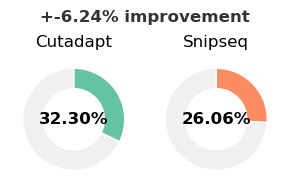

In [6]:
ca_rate = 32.3
ss_rate = 26.06
improvement = ss_rate - ca_rate

ca_data = [ca_rate, 100 - ca_rate]
ss_data = [ss_rate, 100 - ss_rate]

# Colors
colors = ['#66c2a5', '#f0f0f0']
tool_colors = ['#fc8d62', '#f0f0f0']

fig, axs = plt.subplots(1, 2, figsize=(3, 3))

axs[0].pie(ca_data, colors=colors, startangle=90, counterclock=False,
           wedgeprops=dict(width=0.4, edgecolor='white'))
axs[0].text(0, 0, f"{ca_rate:.2f}%", ha='center', va='center', fontsize=12, weight='bold')
axs[0].set_title("Cutadapt", fontsize=12)

axs[1].pie(ss_data, colors=tool_colors, startangle=90, counterclock=False,
           wedgeprops=dict(width=0.4, edgecolor='white'))
axs[1].text(0, 0, f"{ss_rate:.2f}%", ha='center', va='center', fontsize=12, weight='bold')
axs[1].set_title("Snipseq", fontsize=12)

#Add improvement arrow/text
fig.text(0.5, 0.84, f"+{improvement:.2f}% improvement", ha='center', va='center', fontsize=12, weight='bold', color='#333')

# Remove axes
for ax in axs:
    ax.set(aspect="equal")

plt.tight_layout()
#plt.savefig("recovery_rate_com_donut.png", dpi=300, bbox_inches='tight')
plt.show()

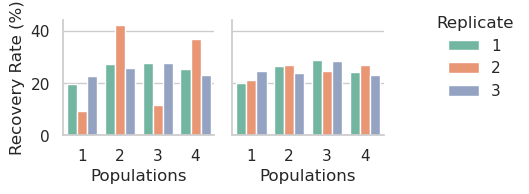

In [50]:
sns.set(style="whitegrid")
g = sns.FacetGrid(data=df_pop,col="tools",height=2,aspect=0.8,sharey=True)

g.map_dataframe(sns.barplot,x="pop",y="proportion",hue="rep",errorbar=("ci", 95),
                estimator="mean",dodge=True,palette="Set2")

g.set_axis_labels("Populations", "Recovery Rate (%)")
g.set_titles("")
g.add_legend(title="Replicate", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
# plt.savefig("recovery_rate_com_bar.png", dpi=300, bbox_inches='tight')
plt.show()

## Minimap2

### Figure 6.6(C)

In [9]:
# This file contain both minimap2 and snipseq outputs
df_e1_unique = pd.read_csv('/home/chiga034/projects_limgroup/gab/2025/mutagenesis_pool/regex/df_e1_unique.csv')
df_e1_unique['seq_len'] = df_e1_unique.seq.str.len()
df_e1_unique['seq_len'].agg(['mean', 'std', 'min', 'max', 'median', 'count'])

mean         823.955929
std          115.811769
min          745.000000
max         5236.000000
median       816.000000
count     756443.000000
Name: seq_len, dtype: float64

In [10]:
def find_all_variant_positions(row):
    mm = row['variants_mmi']
    ss = row['variant']
    full_read = row['seq']
    
    mm_positions = [i for i in range(len(full_read)) if full_read.startswith(mm, i)]
    ss_positions = [i for i in range(len(full_read)) if full_read.startswith(ss, i)]
    
    return pd.Series([mm_positions, ss_positions, len(mm_positions), len(ss_positions)])

df_e1_unique[['mm_pos', 'ss_pos', 'mm_occ', 'ss_occ']] = df_e1_unique.apply(find_all_variant_positions, axis=1)

In [11]:
df_e1_unique['first_pos_mm'] = df_e1_unique.mm_pos.apply(lambda x: x[0] if len(x)>0 else -1)
df_e1_unique['first_pos_ss'] = df_e1_unique.ss_pos.apply(lambda x: x[0] if len(x)>0 else -1)

In [12]:
# First, melt first position columns
df_long_first_pos = df_e1_unique.melt(
    id_vars=['rep', 'pop'],
    value_vars=['first_pos_mm', 'first_pos_ss'],
    var_name='tools',
    value_name='first_pos'
)

# Then, melt the occurance columns
df_long_occ = df_e1_unique.melt(
    id_vars=['rep', 'pop'],
    value_vars=['mm_occ', 'ss_occ'],
    var_name='tools',
    value_name='occcurance'
)

# Clean up the 'type' column so it matches between the two (remove prefix)
df_long_first_pos['tools'] = df_long_first_pos['tools'].str.replace('first_pos_', '')
df_long_occ['tools'] = df_long_occ['tools'].str.replace('_occ', '')

# Combine both
df_long = df_long_first_pos.copy()
df_long['occcurance'] = df_long_occ['occcurance'].values

# Optional: reset index if needed
df_long.reset_index(drop=True, inplace=True)

In [13]:
def classify_mapping(occ):
    if occ > 1:
        return "multi_hit"
    elif occ == 1:
        return "uniquely_assigned"
    else:
        return "unassigned"

df_long['status'] = df_long['occcurance'].apply(classify_mapping)

In [14]:
df_long_200 = df_long[df_long.first_pos < 200].groupby(['tools', 'status']).size().reset_index(name='counts')

In [17]:
wide = (
    df_long_200[df_long_200.status!='multi_hit'].pivot(
        index="status",
        columns="tools",
        values="counts"
    )
    .reset_index()[["status", "mm", "ss"]]
)

wide

tools,status,mm,ss
0,unassigned,14057,8731
1,uniquely_assigned,729918,740526
